# **CNN MODEL**

### **Importing Necessary Libraries**

In [19]:
import os
import numpy as np
import random
import tensorflow as tf
from tensorflow.keras.utils import load_img, img_to_array
from sklearn.model_selection import train_test_split

### **Data Loading**

In [21]:
base_dir = r"C:\Users\User\Desktop\CV\data cleaning\yelp_photos\balanced_labeled_photos"
img_height, img_width = 64, 64
min_images_per_class = 5000
class_names = sorted(os.listdir(base_dir))

### **Balancing The Classes**

In [23]:
images = []
labels = []

for label_idx, label_name in enumerate(class_names):
    class_path = os.path.join(base_dir, label_name)
    image_files = os.listdir(class_path)
    random.shuffle(image_files)
    selected_files = image_files[:min_images_per_class]
    
    for file_name in selected_files:
        img_path = os.path.join(class_path, file_name)
        img = load_img(img_path, target_size=(img_height, img_width))
        img_array = img_to_array(img) / 255.0
        images.append(img_array)
        labels.append(label_idx)

In [25]:
X = np.array(images)
y = tf.keras.utils.to_categorical(np.array(labels), num_classes=len(class_names))

### **Data Splitting**

In [27]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [29]:
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).batch(32).shuffle(1000)
val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(32)

In [31]:
print(f"Train shape: {X_train.shape}, Validation shape: {X_val.shape}")

Train shape: (20000, 64, 64, 3), Validation shape: (5000, 64, 64, 3)


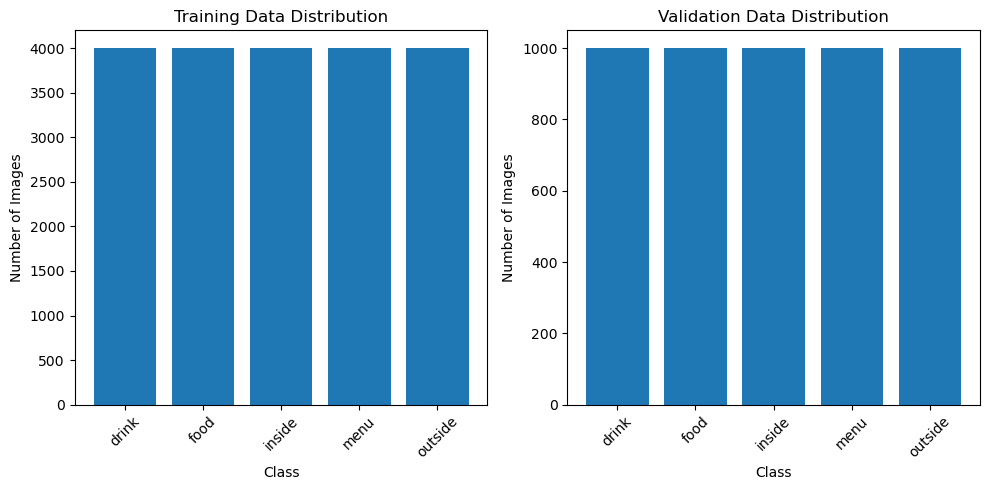

In [37]:
train_class_counts = np.array([4000, 4000, 4000, 4000, 4000])  # 5 classes balanced in train
val_class_counts = np.array([1000, 1000, 1000, 1000, 1000])    # 5 classes balanced in val
class_names = ['drink', 'food', 'inside', 'menu', 'outside']

# Plotting class distribution
plt.figure(figsize=(10, 5))

# Training set distribution
plt.subplot(1, 2, 1)
plt.bar(class_names, train_class_counts)
plt.title("Training Data Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)

# Validation set distribution
plt.subplot(1, 2, 2)
plt.bar(class_names, val_class_counts)
plt.title("Validation Data Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### **CNN Model Building**

In [39]:
def build_cnn_model():
    model = models.Sequential([
        layers.Input(shape=(64, 64, 3)),
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(5, activation='softmax')  # 5 classes
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

In [41]:
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', patience=3, factor=0.3)

In [45]:
model = build_cnn_model()
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 266s 406ms/step - accuracy: 0.5622 - loss: 1.3252 - val_accuracy: 0.7610 - val_loss: 0.6438 - learning_rate: 0.0010
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 260s 414ms/step - accuracy: 0.7724 - loss: 0.6291 - val_accuracy: 0.5888 - val_loss: 1.4705 - learning_rate: 0.0010
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 234s 372ms/step - accuracy: 0.8140 - loss: 0.5128 - val_accuracy: 0.8464 - val_loss: 0.4537 - learning_rate: 0.0010
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 263s 420ms/step - accuracy: 0.8478 - loss: 0.4368 - val_accuracy: 0.7760 - val_loss: 0.7203 - learning_rate: 0.0010
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 253s 402ms/step - accuracy: 0.8606 - loss: 0.3854 - val_accuracy: 0.7262 - val_loss: 0.7077 - learning_rate: 0.0010
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 166s 263ms/step - accuracy: 0.8750 - loss: 0.3525 - val_accuracy: 0.7946 - val_loss: 0.5708 - learning_rate: 0.0010
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 111s 177ms/step - accura

In [47]:
#Evaluation
y_true = np.concatenate([y for _, y in val_ds], axis=0)
y_pred_probs = model.predict(val_ds)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true_labels = np.argmax(y_true, axis=1)

157/157 ━━━━━━━━━━━━━━━━━━━━ 18s 109ms/step


### **Confusion Matrix**

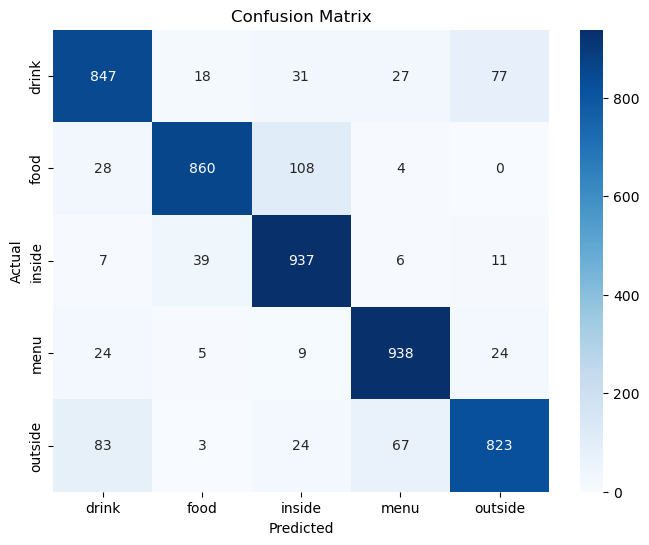

In [49]:
# Confusion Matrix
cm = confusion_matrix(y_true_labels, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### **AUC Score & Other Metrics**

In [51]:
# AUC Score
auc_score = roc_auc_score(y_true, y_pred_probs, multi_class='ovr')
print(f"AUC Score: {auc_score:.4f}")

AUC Score: 0.9838


In [53]:
# Classification Report
print("\nClassification Report:\n", classification_report(y_true_labels, y_pred, target_names=class_names))


Classification Report:
               precision    recall  f1-score   support

       drink       0.86      0.85      0.85      1000
        food       0.93      0.86      0.89      1000
      inside       0.84      0.94      0.89      1000
        menu       0.90      0.94      0.92      1000
     outside       0.88      0.82      0.85      1000

    accuracy                           0.88      5000
   macro avg       0.88      0.88      0.88      5000
weighted avg       0.88      0.88      0.88      5000



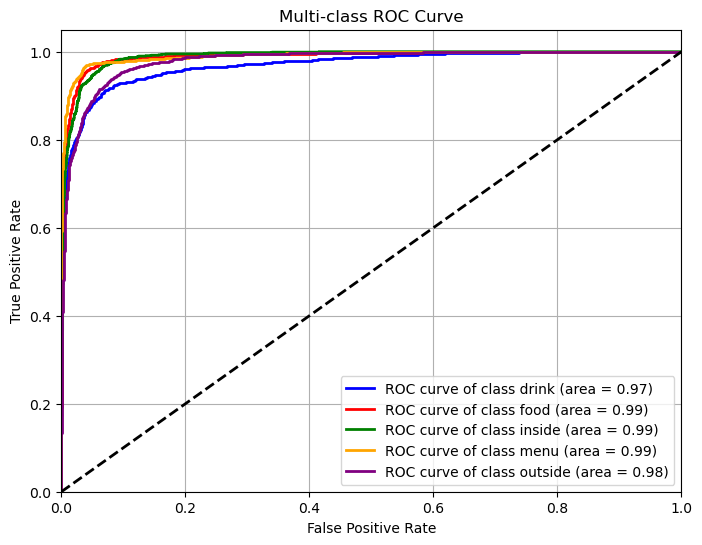

In [55]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np

fpr = dict()
tpr = dict()
roc_auc = dict()
n_classes = len(class_names)

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(8, 6))
colors = ['blue', 'red', 'green', 'orange', 'purple']

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curve of class {class_names[i]} (area = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)  # Diagonal line (random classifier)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

### **CNN Model Tuning**

In [57]:
from tensorflow.keras import optimizers

def build_model_round2():
    model = models.Sequential([
        layers.Input(shape=(64, 64, 3)),
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        # New Conv2D(256) layer added
        layers.Conv2D(256, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),  # Increased dropout for regularization
        layers.Dense(5, activation='softmax')
    ])

    # Use RMSprop optimizer with tuned learning rate
    optimizer = optimizers.RMSprop(learning_rate=1e-4)

    model.compile(optimizer=optimizer,
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

In [61]:
model_round2 = build_model_round2()
history_round2 = model_round2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 283s 437ms/step - accuracy: 0.4826 - loss: 1.5620 - val_accuracy: 0.6580 - val_loss: 0.9033 - learning_rate: 1.0000e-04
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 232s 370ms/step - accuracy: 0.6884 - loss: 0.8407 - val_accuracy: 0.7220 - val_loss: 0.7638 - learning_rate: 1.0000e-04
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 230s 366ms/step - accuracy: 0.7757 - loss: 0.6143 - val_accuracy: 0.7686 - val_loss: 0.6333 - learning_rate: 1.0000e-04
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 183s 291ms/step - accuracy: 0.8150 - loss: 0.5068 - val_accuracy: 0.7988 - val_loss: 0.5635 - learning_rate: 1.0000e-04
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 305s 485ms/step - accuracy: 0.8583 - loss: 0.3893 - val_accuracy: 0.7808 - val_loss: 0.6061 - learning_rate: 1.0000e-04
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 278s 443ms/step - accuracy: 0.8952 - loss: 0.2924 - val_accuracy: 0.8074 - val_loss: 0.5660 - learning_rate: 1.0000e-04
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 

In [67]:
def build_model_round3():
    model = models.Sequential([
        layers.Input(shape=(64, 64, 3)),

        layers.Conv2D(32, (3, 3)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(64, (3, 3)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(128, (3, 3)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(256, (3, 3)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(2, 2),

        layers.Flatten(),
        layers.Dense(256),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.6),  # Slightly higher dropout

        layers.Dense(5, activation='softmax')
    ])

    # Lower learning rate to 5e-5 for finer tuning
    optimizer = optimizers.RMSprop(learning_rate=5e-5)

    model.compile(optimizer=optimizer,
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# Train Round 3 model
model_round3 = build_model_round3()
history_round3 = model_round3.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 232s 352ms/step - accuracy: 0.4371 - loss: 1.5711 - val_accuracy: 0.6258 - val_loss: 1.0153 - learning_rate: 5.0000e-05
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 289s 458ms/step - accuracy: 0.6304 - loss: 1.0324 - val_accuracy: 0.7000 - val_loss: 0.8291 - learning_rate: 5.0000e-05
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 203s 324ms/step - accuracy: 0.6880 - loss: 0.8608 - val_accuracy: 0.7262 - val_loss: 0.7501 - learning_rate: 5.0000e-05
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 237s 378ms/step - accuracy: 0.7376 - loss: 0.7329 - val_accuracy: 0.7460 - val_loss: 0.6910 - learning_rate: 5.0000e-05
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 114s 181ms/step - accuracy: 0.7690 - loss: 0.6363 - val_accuracy: 0.7752 - val_loss: 0.6314 - learning_rate: 5.0000e-05
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 104s 166ms/step - accuracy: 0.8053 - loss: 0.5361 - val_accuracy: 0.7828 - val_loss: 0.5964 - learning_rate: 5.0000e-05
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 

### **Model Saving**

In [81]:
save_path = r"C:\Users\User\Downloads\cnn_final_model.h5" 

# Save the model
model.save(save_path)

print(f"Model saved at: {save_path}")

Model saved at: C:\Users\User\Downloads\cnn_final_model.h5


### **Model Prediction**

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step


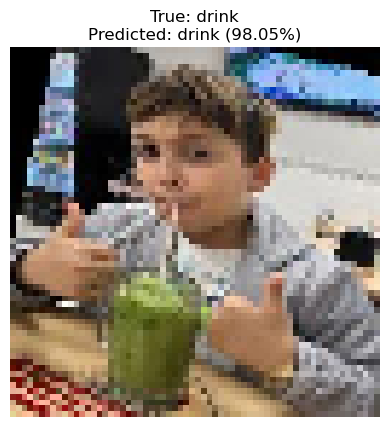

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step


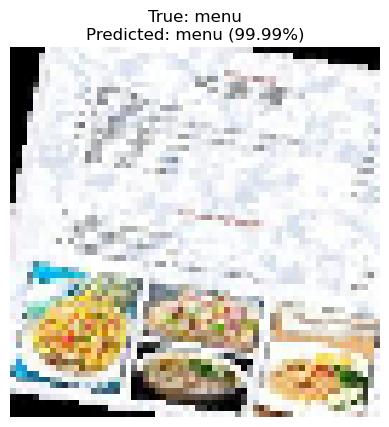

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step


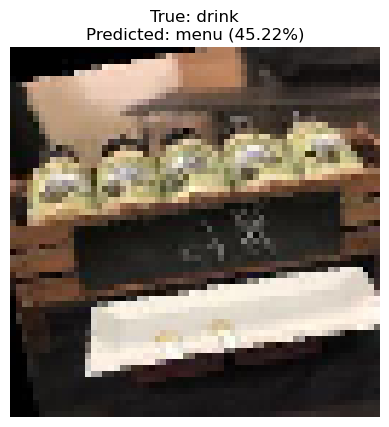

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step


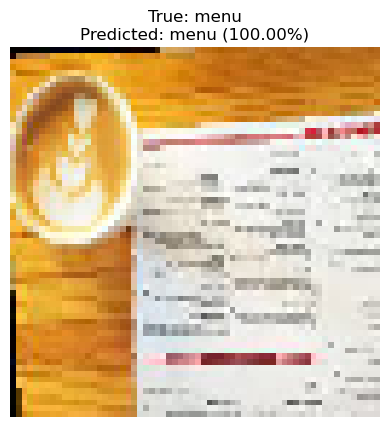

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step


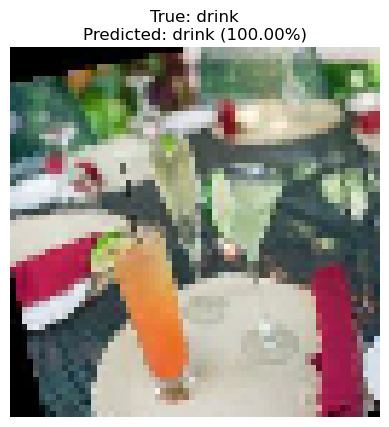

In [85]:
import os
import random
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import matplotlib.pyplot as plt

# Define variables
dataset_dir = r"C:\Users\User\Desktop\CV\data cleaning\yelp_photos\balanced_labeled_photos"  # replace with your actual path
img_height, img_width = 64, 64
class_names = sorted(os.listdir(dataset_dir))
model_path = r"C:\Users\User\Downloads\cnn_final_model.h5"  # your saved model file

# Load your trained model
model = tf.keras.models.load_model(model_path)

def predict_random_images(num_images=5):
    for _ in range(num_images):
        # Pick random class folder
        random_class = random.choice(class_names)
        class_dir = os.path.join(dataset_dir, random_class)
        
        # Pick random image from that class
        random_image_name = random.choice(os.listdir(class_dir))
        img_path = os.path.join(class_dir, random_image_name)
        
        # Load and preprocess image
        img = load_img(img_path, target_size=(img_height, img_width))
        img_array = img_to_array(img) / 255.0
        img_input = np.expand_dims(img_array, axis=0)  # batch dimension
        
        # Predict
        pred_probs = model.predict(img_input)[0]
        pred_class_idx = np.argmax(pred_probs)
        pred_class = class_names[pred_class_idx]
        confidence = pred_probs[pred_class_idx]
        
        # Display image with prediction
        plt.imshow(img)
        plt.title(f"True: {random_class}\nPredicted: {pred_class} ({confidence*100:.2f}%)")
        plt.axis('off')
        plt.show()

# Example: Predict 5 random images
predict_random_images(5)

**LLM Prompts used**
- How can I balance my dataset in training and test sets
- How can I correctly format one-hot encoded labels and predictions for roc_auc_score?
- Types of tunning for CNN model
- How do I pick random images from my dataset folder to do prediction